<a href="https://colab.research.google.com/github/kyliequinney/MachineLearning4375/blob/main/4375Project/4375_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

“The objective is to predict whether a ClinVar variant will have conflicting classifications. This is presented here as a binary classification problem, where each record in the dataset is a genetic variant.”

Link to dataset: https://www.kaggle.com/datasets/kevinarvai/clinvar-conflicting



# Preprocessing

In [ ]:
# import dataset
import pandas as pd
df = pd.read_csv('https://utdallas.box.com/shared/static/i2qyjdjml87i843jkqu882c0bihqahw7.csv')

<ipython-input-2-0fd55c4694c0>:3: DtypeWarning: Columns (0,38,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://utdallas.box.com/shared/static/i2qyjdjml87i843jkqu882c0bihqahw7.csv')


In [ ]:
df.head()

,CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,CLNDISDB,CLNDISDBINCL,CLNDN,...,SIFT,PolyPhen,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,LoFtool,CADD_PHRED,CADD_RAW,BLOSUM62
0,1,1168180,G,C,0.0771,0.10020,0.1066,MedGen:CN169374,NaN,not_specified,...,tolerated,benign,NaN,NaN,NaN,NaN,NaN,1.053,-0.208682,2.0
1,1,1470752,G,A,0.0000,0.00000,0.0000,"MedGen:C1843891,OMIM:607454,Orphanet:ORPHA9877...",NaN,Spinocerebellar_ataxia_21|not_provided,...,deleterious_low_confidence,benign,NaN,NaN,NaN,NaN,NaN,31.000,6.517838,-3.0
2,1,1737942,A,G,0.0000,0.00001,0.0000,"Human_Phenotype_Ontology:HP:0000486,MedGen:C00...",NaN,Strabismus|Nystagmus|Hypothyroidism|Intellectu...,...,deleterious,probably_damaging,NaN,NaN,NaN,NaN,NaN,28.100,6.061752,-1.0
3,1,2160305,G,A,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002...",NaN,Shprintzen-Goldberg_syndrome|not_provided,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.500,3.114491,NaN
4,1,2160305,G,T,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002",NaN,Shprintzen-Goldberg_syndrome,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.700,4.766224,-3.0


In [ ]:
# check for null values
df.isnull().sum()

,0
CHROM,0
POS,0
REF,0
ALT,0
AF_ESP,0
AF_EXAC,0
AF_TGP,0
CLNDISDB,0
CLNDISDBINCL,65021
CLNDN,0


In [ ]:
# check for missing data
df.isna().sum()

,0
CHROM,0
POS,0
REF,0
ALT,0
AF_ESP,0
AF_EXAC,0
AF_TGP,0
CLNDISDB,0
CLNDISDBINCL,65021
CLNDN,0


In [ ]:
#display each variable's datatype and percentage of missing data
var_df = pd.DataFrame(columns=['variable', 'data_type', 'missing_percentage'])

missing_percentages = df.isnull().mean() * 100
missing_percentages = missing_percentages.sort_values(ascending=False)

for col in df.columns:
    data_type = df[col].dtype
    missing_percentage = missing_percentages[col]
    var_df = pd.concat([var_df, pd.DataFrame({'variable': [col], 'data_type': [data_type], 'missing_percentage': [missing_percentage]})], ignore_index=True)

var_df

<ipython-input-6-4ff39d587c2e>:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  var_df = pd.concat([var_df, pd.DataFrame({'variable': [col], 'data_type': [data_type], 'missing_percentage': [missing_percentage]})], ignore_index=True)


,variable,data_type,missing_percentage
0,CHROM,object,0.000000
1,POS,int64,0.000000
2,REF,object,0.000000
3,ALT,object,0.000000
4,AF_ESP,float64,0.000000
5,AF_EXAC,float64,0.000000
6,AF_TGP,float64,0.000000
7,CLNDISDB,object,0.000000
8,CLNDISDBINCL,object,99.743818
9,CLNDN,object,0.000000


In [ ]:
var_df_sorted = var_df.sort_values(by='missing_percentage')
var_df_sorted.reset_index(drop=True, inplace=True)

var_df_sorted

,variable,data_type,missing_percentage
0,CHROM,object,0.000000
1,POS,int64,0.000000
2,REF,object,0.000000
3,ALT,object,0.000000
4,AF_ESP,float64,0.000000
5,AF_EXAC,float64,0.000000
6,AF_TGP,float64,0.000000
7,CLNDISDB,object,0.000000
8,CLNDN,object,0.000000
9,CLNHGVS,object,0.000000


In [ ]:
var_df = var_df_sorted.copy()

# Drop columns with missing percentages higher than 99%
var_df = var_df[var_df['missing_percentage'] <= 99]

threshold = 99

#drop in main df as well
missing_percentages = df.isnull().mean() * 100
columns_to_drop = missing_percentages[missing_percentages > 99].index.tolist()

df = df.drop(columns=columns_to_drop)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65188 entries, 0 to 65187
Data columns (total 37 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CHROM             65188 non-null  object 
 1   POS               65188 non-null  int64  
 2   REF               65188 non-null  object 
 3   ALT               65188 non-null  object 
 4   AF_ESP            65188 non-null  float64
 5   AF_EXAC           65188 non-null  float64
 6   AF_TGP            65188 non-null  float64
 7   CLNDISDB          65188 non-null  object 
 8   CLNDN             65188 non-null  object 
 9   CLNHGVS           65188 non-null  object 
 10  CLNVC             65188 non-null  object 
 11  CLNVI             27659 non-null  object 
 12  MC                64342 non-null  object 
 13  ORIGIN            65188 non-null  int64  
 14  CLASS             65188 non-null  int64  
 15  Allele            65188 non-null  object 
 16  Consequence       65188 non-null  object

In [ ]:
#drop unnecessary columns (do not relate to our project)
df.drop(['BAM_EDIT', 'EXON', 'CLNDISDB', 'CLNHGVS',
         'MC', 'CLNVI', 'SYMBOL', 'Feature', 'Feature_type',
         'BIOTYPE', 'INTRON', 'CADD_RAW'], axis=1, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65188 entries, 0 to 65187
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CHROM             65188 non-null  object 
 1   POS               65188 non-null  int64  
 2   REF               65188 non-null  object 
 3   ALT               65188 non-null  object 
 4   AF_ESP            65188 non-null  float64
 5   AF_EXAC           65188 non-null  float64
 6   AF_TGP            65188 non-null  float64
 7   CLNDN             65188 non-null  object 
 8   CLNVC             65188 non-null  object 
 9   ORIGIN            65188 non-null  int64  
 10  CLASS             65188 non-null  int64  
 11  Allele            65188 non-null  object 
 12  Consequence       65188 non-null  object 
 13  IMPACT            65188 non-null  object 
 14  cDNA_position     56304 non-null  object 
 15  CDS_position      55233 non-null  object 
 16  Protein_position  55233 non-null  object

In [ ]:
#Handle any other missing values
has_missing = pd.DataFrame()

for column in df.columns:
    if df[column].isnull().any():
        has_missing[column] = df[column]

print("Columns with missing values:")
has_missing.info()

Columns with missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65188 entries, 0 to 65187
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cDNA_position     56304 non-null  object 
 1   CDS_position      55233 non-null  object 
 2   Protein_position  55233 non-null  object 
 3   Amino_acids       55184 non-null  object 
 4   Codons            55184 non-null  object 
 5   STRAND            65174 non-null  float64
 6   SIFT              24836 non-null  object 
 7   PolyPhen          24796 non-null  object 
 8   LoFtool           60975 non-null  float64
 9   CADD_PHRED        64096 non-null  float64
 10  BLOSUM62          25593 non-null  float64
dtypes: float64(4), object(7)
memory usage: 5.5+ MB


In [ ]:
df.shape

(65188, 25)

In [ ]:
for column in has_missing.columns:
    if column == 'BLOSUM62':
        #Use firward fill for 'BLOSUM62' column
        has_missing[column] = has_missing[column].fillna(method='ffill')
    elif has_missing[column].dtype == 'float64':
        #Use interpolate method for float64 columns
        has_missing[column] = has_missing[column].interpolate()
    elif has_missing[column].dtype == 'object':
        #Use forward fill for object columns
        has_missing[column] = has_missing[column].fillna(method='ffill')


#Fill with 0's in 'LoFtool' column
has_missing['LoFtool'] = has_missing['LoFtool'].fillna(0)

#Show changes
has_missing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65188 entries, 0 to 65187
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cDNA_position     65188 non-null  object 
 1   CDS_position      65188 non-null  object 
 2   Protein_position  65188 non-null  object 
 3   Amino_acids       65188 non-null  object 
 4   Codons            65188 non-null  object 
 5   STRAND            65188 non-null  float64
 6   SIFT              65188 non-null  object 
 7   PolyPhen          65188 non-null  object 
 8   LoFtool           65188 non-null  float64
 9   CADD_PHRED        65188 non-null  float64
 10  BLOSUM62          65188 non-null  float64
dtypes: float64(4), object(7)
memory usage: 5.5+ MB


<ipython-input-12-7c9dcee040e0>:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  has_missing[column] = has_missing[column].fillna(method='ffill')
<ipython-input-12-7c9dcee040e0>:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  has_missing[column] = has_missing[column].fillna(method='ffill')


In [ ]:
#add updates to main df
df.update(has_missing)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65188 entries, 0 to 65187
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CHROM             65188 non-null  object 
 1   POS               65188 non-null  int64  
 2   REF               65188 non-null  object 
 3   ALT               65188 non-null  object 
 4   AF_ESP            65188 non-null  float64
 5   AF_EXAC           65188 non-null  float64
 6   AF_TGP            65188 non-null  float64
 7   CLNDN             65188 non-null  object 
 8   CLNVC             65188 non-null  object 
 9   ORIGIN            65188 non-null  int64  
 10  CLASS             65188 non-null  int64  
 11  Allele            65188 non-null  object 
 12  Consequence       65188 non-null  object 
 13  IMPACT            65188 non-null  object 
 14  cDNA_position     65188 non-null  object 
 15  CDS_position      65188 non-null  object 
 16  Protein_position  65188 non-null  object

In [ ]:
# removing redundant rows
df.drop_duplicates(inplace=True)
df.shape

(65188, 25)

In [ ]:
# see which columns are non numeric
non_numeric_columns = df.select_dtypes(exclude=['number']).columns
print("Columns with non-numeric values:", non_numeric_columns)

df.dtypes

Columns with non-numeric values: Index(['CHROM', 'REF', 'ALT', 'CLNDN', 'CLNVC', 'Allele', 'Consequence',
       'IMPACT', 'cDNA_position', 'CDS_position', 'Protein_position',
       'Amino_acids', 'Codons', 'SIFT', 'PolyPhen'],
      dtype='object')


,0
CHROM,object
POS,int64
REF,object
ALT,object
AF_ESP,float64
AF_EXAC,float64
AF_TGP,float64
CLNDN,object
CLNVC,object
ORIGIN,int64


In [ ]:
#Use label encoder to replace non-numeric values with numeric
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for column in non_numeric_columns:
    if df[column].dtype == 'object':
      df[column] = df[column].astype(str)
      df[column] = encoder.fit_transform(df[column])

df.dtypes

,0
CHROM,int64
POS,int64
REF,int64
ALT,int64
AF_ESP,float64
AF_EXAC,float64
AF_TGP,float64
CLNDN,int64
CLNVC,int64
ORIGIN,int64


In [ ]:
y = df['CLASS']
X = df.drop(['CLASS'], axis =1)

# Model Construction

In [ ]:
#base class Layer: all other layers will inherit

class Layer:
    def __init__(self):
        self.layerInput = None
        self.layerOutput = None

    def forward_pass(self, layerInput):
        raise NotImplementedError

    def backward_pass(self, outGradient, learningRate):
        raise NotImplementedError

In [ ]:
#Fully Connected Layer
import numpy as np

class FullyConnectedLayer(Layer):
    def __init__(self, inSize, outSize):
      super().__init__()
      self.weights = np.random.randn(inSize, outSize) - 0.5
      self.bias = np.zeros((1, outSize)) - 0.5

    def forward_pass(self, layerInput):
      self.layerInput = layerInput
      matrixMult = np.dot(layerInput, self.weights)
      self.layerOutput = matrixMult + self.bias
      return self.layerOutput

    def backward_pass(self, outGradient, learningRate):
      if self.layerInput.ndim == 1:
            self.layerInput = self.layerInput.reshape(1, -1)

      weightGradient = np.dot(self.layerInput.T, outGradient)
      biasGradient = np.sum(outGradient, axis = 0, keepdims = True)
      inGradient = np.dot(outGradient, self.weights.T)
      self.weights -= learningRate * weightGradient
      self.bias -= learningRate * biasGradient

      return inGradient



In [ ]:
#Activation Layer
class ActivationLayer(Layer):
    def __init__(self, activationFunction):
        super().__init__()
        self.activationFunction = activationFunction

    def forward_pass(self, layerInput):
        self.layerInput = layerInput
        self.layerOutput = self.activationFunction(self.layerInput)
        return self.layerOutput

    def backward_pass(self, outGradient, learningRate = None):
        if self.activationFunction == relu:
            activationDerivative = (self.layerInput > 0).astype(float)
        elif self.activationFunction == sigmoid:
            activationDerivative = self.layerOutput * (1 - self.layerOutput)
        else:
            raise ValueError("Unsupported activation function")

        return activationDerivative * outGradient


In [ ]:
# Activation Functions
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
# Loss Functions
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def dmse(y_true, y_pred):
    return 2 * (y_pred - y_true) / y_true.size

def rmse(y_true, y_pred):
    return np.sqrt(np.mean(np.power(y_true - y_pred, 2)))

def drmse(y_true, y_pred, epsilon = 1e-8):
    return (y_pred - y_true) / (y_true.size * np.sqrt(np.mean(np.power(y_true - y_pred, 2))) + epsilon)

def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-15  # Small value to avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # Clip predictions to avoid numerical issues
    loss = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return np.mean(loss)

def dbinary_cross_entropy(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return (y_pred - y_true) / (y_pred * (1 - y_pred))


In [ ]:
# Network Class
import matplotlib.pyplot as plt

# allows you to easily initialize a network
class Network:
    def __init__(self):
        self.layers = []
        self.loss = None
        self.lossPrime = None

        #add layer
    def add(self, layer):
        self.layers.append(layer)

        #set loss
    def use(self, loss, lossPrime):
        self.loss = loss
        self.lossPrime = lossPrime

        #predict output for given input
    def predict(self, inData):
        samples = len(inData)
        result = []

        #run network over all samples
        for i in range(samples):
            #forward pass
            layerOutput = inData[i]
            for layer in self.layers:
                layerOutput = layer.forward_pass(layerOutput)
            result.append(layerOutput)

        return result

    # train the model
    def fit(self, x_train, y_train, epochs, learningRate):
        # get number of samples
        numSamples = len(x_train)
        rmseHistory = []
        epochHistory = []
        # training loop
        for i in range(epochs):
          totalLoss = 0
          correctPredictions = 0
          for j in range(numSamples):
              # forward pass
              layerOutput = self._forward(x_train[j])

              outputScalar = layerOutput[0] if isinstance(layerOutput, (np.ndarray, list)) else layerOutput

              totalLoss += self.loss(y_train.iloc[j], outputScalar)

              predictedLabel = 1 if outputScalar >= 0.5 else 0
              actualLabel = y_train.iloc[j]

              if predictedLabel == actualLabel:
                  correctPredictions += 1

              # backward pass
              error = self.lossPrime(y_train.iloc[j], layerOutput)
              for layer in reversed(self.layers):
                  error = layer.backward_pass(error, learningRate)

          # Compute average loss for this epoch
          avgLoss = totalLoss / numSamples
          rmseHistory.append(avgLoss)
          epochHistory.append(i+1)

          accuracy = correctPredictions / numSamples
          print(f'Epoch {i+1}/{epochs} - Error (RMSE): {avgLoss:.6f} - Accuracy: {accuracy:.2f}')

        plt.plot(epochHistory, rmseHistory)
        plt.xlabel('Epoch')
        plt.ylabel('RMSE')
        plt.title('RMSE vs. Epoch')
        plt.show()


    def _forward(self, inData):
        layerOutput = inData
        for layer in self.layers:
            layerOutput = layer.forward_pass(layerOutput)
        return layerOutput

    def _backward(self, error, learningRate):
        for layer in reversed(self.layers):
            error = layer.backward_pass(error, learningRate)

Epoch 1/40 - Error (RMSE): 0.704591 - Accuracy: 0.52
Epoch 2/40 - Error (RMSE): 0.684762 - Accuracy: 0.53
Epoch 3/40 - Error (RMSE): 0.677814 - Accuracy: 0.55
Epoch 4/40 - Error (RMSE): 0.674561 - Accuracy: 0.55
Epoch 5/40 - Error (RMSE): 0.672143 - Accuracy: 0.56
Epoch 6/40 - Error (RMSE): 0.670039 - Accuracy: 0.56
Epoch 7/40 - Error (RMSE): 0.668108 - Accuracy: 0.57
Epoch 8/40 - Error (RMSE): 0.665949 - Accuracy: 0.57
Epoch 9/40 - Error (RMSE): 0.663480 - Accuracy: 0.58
Epoch 10/40 - Error (RMSE): 0.661629 - Accuracy: 0.58
Epoch 11/40 - Error (RMSE): 0.660107 - Accuracy: 0.58
Epoch 12/40 - Error (RMSE): 0.658707 - Accuracy: 0.59
Epoch 13/40 - Error (RMSE): 0.657441 - Accuracy: 0.59
Epoch 14/40 - Error (RMSE): 0.656346 - Accuracy: 0.59
Epoch 15/40 - Error (RMSE): 0.655371 - Accuracy: 0.59
Epoch 16/40 - Error (RMSE): 0.654620 - Accuracy: 0.59
Epoch 17/40 - Error (RMSE): 0.653798 - Accuracy: 0.59
Epoch 18/40 - Error (RMSE): 0.652861 - Accuracy: 0.59
Epoch 19/40 - Error (RMSE): 0.652128 

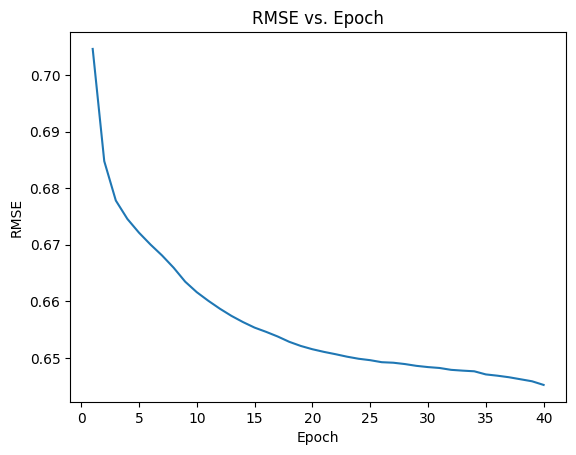

Final Test Accuracy: 0.59
Final Test RMSE: 0.642407


In [ ]:
#Evaluation
!pip install -U imbalanced-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score

# Apply under_sampling to handle class imbalance (far more negative samples than positive)
from imblearn.under_sampling import RandomUnderSampler
undersampler = RandomUnderSampler(sampling_strategy={0:16434, 1:16434}, random_state = 42)

# Resample the data
X_resampled, y_resampled = undersampler.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.20, random_state = 1)

#scale after train test split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnet = Network()
nnet.add(FullyConnectedLayer(24, 12))
nnet.add(ActivationLayer(relu))

nnet.add(FullyConnectedLayer(12, 8))
nnet.add(ActivationLayer(relu))

nnet.add(FullyConnectedLayer(8, 1))
nnet.add(ActivationLayer(sigmoid))

nnet.use(binary_cross_entropy, dbinary_cross_entropy)
nnet.fit(X_train, y_train, epochs = 40, learningRate = 0.005)

test_pred = nnet.predict(X_test)
test_pred = [1 if (pred[0] if isinstance(pred, (np.ndarray, list)) else pred) >= 0.5 else 0 for pred in test_pred]

print(f'Final Test Accuracy: {accuracy_score(y_test, test_pred):.2f}')
print(f'Final Test RMSE: {rmse(y_test, test_pred):.6f}')


[[1100 2256]
 [ 457 2761]]


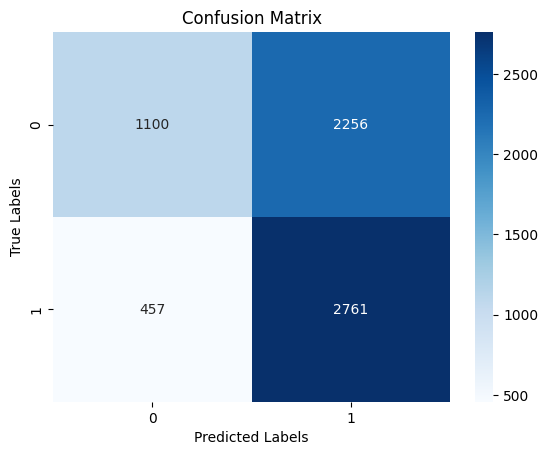

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, test_pred)
print(conf_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(df['CLASS'].value_counts())
print(y_resampled.value_counts())

CLASS
0    48754
1    16434
Name: count, dtype: int64
CLASS
0    16434
1    16434
Name: count, dtype: int64
